In [1]:
import sys
from pathlib import Path

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import numpy as np
import matplotlib.pyplot as plt
from pricing.binomial import crr_binomial
from pricing.black_scholes import black_scholes

In [2]:
# Parameters for the American put option
S0 = 100
K = 100
T = 1.0
r = 0.05
sigma = 0.2
n = 100
option_type = 'put'
exercise_type = 'american'

In [3]:
crr_price = crr_binomial(S0, K, T, r, sigma, n, option_type, exercise_type)
print(f"American put price using Binomial Model: {crr_price}")
# Sanity check: Compare with Black-Scholes price for European put option
eu_price = black_scholes(S0, K, T, r, sigma, option_type='put')
print(f" Corresponding European put price: {eu_price}")

American put price using Binomial Model: 6.082354409142418
 Corresponding European put price: 5.573526022256971


In [4]:
# Non-dividend american call vs european call
option_type = 'call'
crr_price_call = crr_binomial(S0, K, T, r, sigma, n, option_type, exercise_type)
print(f"American call price using Binomial Model: {crr_price_call}")
eu_price_call = black_scholes(S0, K, T, r, sigma, option_type='call')
print(f" Corresponding European call price: {eu_price_call}")

American call price using Binomial Model: 10.430611662249113
 Corresponding European call price: 10.450583572185565


## Performance: vectorized induction vs explicit loops

Both engines are O(N^2) in the number of nodes. The difference is the constant:
`crr_binomial` collapses each level with one NumPy expression, while
`crr_binomial_reference` walks node by node in Python.

In [5]:
import timeit
from pricing.binomial import crr_binomial_reference

S0, K, T, r, sigma, q = 100.0, 100.0, 1.0, 0.05, 0.2, 0.0

print(f"{'N':>6} {'vectorized (ms)':>17} {'reference (ms)':>16} {'speedup':>9}")
for N in (10, 25, 50, 100, 200, 400):
    t_vec = min(timeit.repeat(
        lambda: crr_binomial(S0, K, T, r, sigma, N, 'put', 'american', q),
        number=5, repeat=3)) / 5 * 1e3
    t_ref = min(timeit.repeat(
        lambda: crr_binomial_reference(S0, K, T, r, sigma, N, 'put', 'american', q),
        number=1, repeat=3)) * 1e3
    print(f"{N:6d} {t_vec:17.3f} {t_ref:16.3f} {t_ref / t_vec:8.0f}x")

     N   vectorized (ms)   reference (ms)   speedup
    10             0.081            0.166        2x
    25             0.189            0.852        4x
    50             0.372            3.201        9x
   100             0.740           12.553       17x


   200             1.552           49.970       32x


   400             3.294          202.482       61x


In [6]:
# Same price, so the speedup is free. This is the cross-check the tests automate.
for N in (10, 50, 200):
    fast = crr_binomial(S0, K, T, r, sigma, N, 'put', 'american', q)
    slow = crr_binomial_reference(S0, K, T, r, sigma, N, 'put', 'american', q)
    print(f"N={N:4d}  vectorized={fast:.12f}  reference={slow:.12f}  diff={abs(fast-slow):.2e}")

# Scaling: the node count is O(N^2), but the vectorized engine also pays a
# fixed NumPy call overhead on each of its N levels. At these sizes both
# terms matter, so doubling N costs ~2.3x rather than the asymptotic 4x;
# the ratio climbs toward 4x as N grows (~3.0x by N=16000).
%timeit -n 3 -r 3 crr_binomial(S0, K, T, r, sigma, 1000, 'put', 'american', q)
%timeit -n 3 -r 3 crr_binomial(S0, K, T, r, sigma, 2000, 'put', 'american', q)

N=  10  vectorized=6.004259020183  reference=6.004259020183  diff=7.11e-15
N=  50  vectorized=6.073727985725  reference=6.073727985725  diff=4.09e-14
N= 200  vectorized=6.086382749916  reference=6.086382749916  diff=3.73e-14
9.34 ms ± 62.9 μs per loop (mean ± std. dev. of 3 runs, 3 loops each)


21.1 ms ± 154 μs per loop (mean ± std. dev. of 3 runs, 3 loops each)


## Visualizing the lattice

`crr_binomial_reference(..., return_tree=True)` returns the full triangular
lattice alongside the price, so the tree can be drawn directly.

A node is an **early-exercise node** when its value equals its intrinsic value:
the backward induction took the `max` in favour of exercising. Plotting those
nodes traces the exercise boundary, which is never solved for explicitly - it
falls out of the recursion.

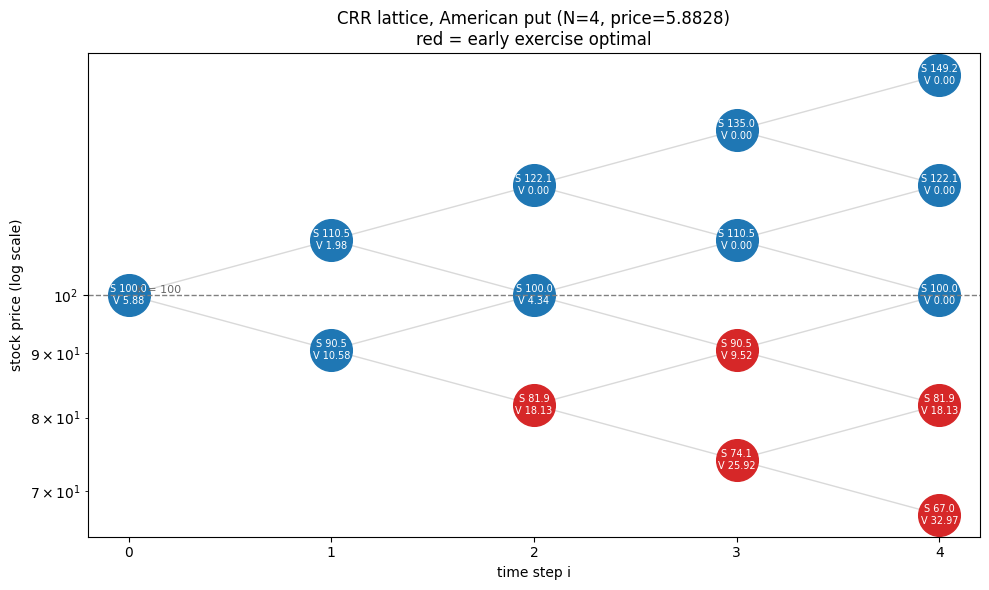

In [7]:
price, S_tree, V_tree = crr_binomial_reference(
    S0, K, T, r, sigma, N=4, option_type='put', exercise_type='american',
    q=q, return_tree=True)

N = 4
intrinsic = np.maximum(K - S_tree, 0.0)
exercise = np.isclose(V_tree, intrinsic, rtol=1e-12, atol=1e-12) & (intrinsic > 0)

fig, ax = plt.subplots(figsize=(10, 6))
for i in range(N):
    for j in range(i + 1):
        for j_child in (j, j + 1):                       # down, up
            ax.plot([i, i + 1], [S_tree[i, j], S_tree[i + 1, j_child]],
                    color='0.85', lw=1, zorder=1)

for i in range(N + 1):
    for j in range(i + 1):
        colour = 'tab:red' if exercise[i, j] else 'tab:blue'
        ax.scatter(i, S_tree[i, j], s=900, color=colour, zorder=2)
        ax.annotate(f"S {S_tree[i, j]:.1f}\nV {V_tree[i, j]:.2f}",
                    (i, S_tree[i, j]), ha='center', va='center',
                    fontsize=7, color='white', zorder=3)

ax.axhline(K, ls='--', color='0.5', lw=1)
ax.text(0.02, K, f' K = {K:.0f}', va='bottom', fontsize=8, color='0.4')
ax.set_yscale('log')                    # recombining tree is a lattice in log-space
ax.set_xlabel('time step i'); ax.set_ylabel('stock price (log scale)')
ax.set_title(f'CRR lattice, American put (N={N}, price={price:.4f})\n'
             'red = early exercise optimal')
ax.set_xticks(range(N + 1))
plt.tight_layout(); plt.show()

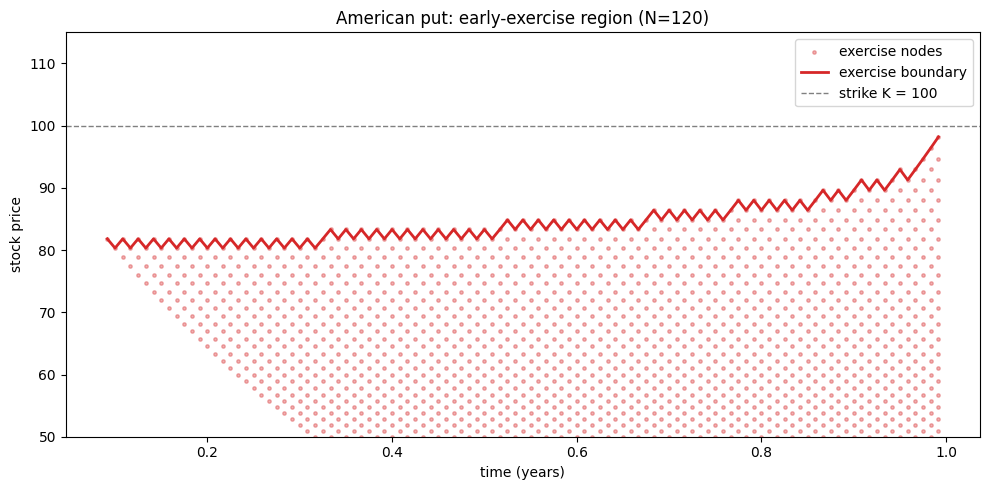

boundary at t=0:        81.81
boundary near expiry:   98.19   (approaches K = 100)


In [8]:
# With more steps the exercise nodes trace out the free boundary.
N_fine = 120
_, S_fine, V_fine = crr_binomial_reference(
    S0, K, T, r, sigma, N=N_fine, option_type='put', exercise_type='american',
    q=q, return_tree=True)

intrinsic = np.maximum(K - S_fine, 0.0)
exercise = np.isclose(V_fine, intrinsic, rtol=1e-12, atol=1e-12) & (intrinsic > 0)
dt = T / N_fine

times, boundary, ex_t, ex_S = [], [], [], []
for i in range(N_fine):                                  # exclude expiry itself
    js = [j for j in range(i + 1) if exercise[i, j]]
    if js:
        times.append(i * dt)
        boundary.append(S_fine[i, max(js)])              # highest exercised price
    for j in range(i + 1):
        if exercise[i, j]:
            ex_t.append(i * dt); ex_S.append(S_fine[i, j])

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(ex_t, ex_S, s=6, color='tab:red', alpha=0.35, label='exercise nodes')
ax.plot(times, boundary, color='tab:red', lw=2, label='exercise boundary')
ax.axhline(K, ls='--', color='0.5', lw=1, label=f'strike K = {K:.0f}')
ax.set_xlabel('time (years)'); ax.set_ylabel('stock price')
ax.set_title(f'American put: early-exercise region (N={N_fine})')
ax.legend(); ax.set_ylim(0.5 * K, 1.15 * K)
plt.tight_layout(); plt.show()

print(f"boundary at t=0:        {boundary[0]:.2f}")
print(f"boundary near expiry:   {boundary[-1]:.2f}   (approaches K = {K:.0f})")